### section2.3
- BPE解决了序列长度过长（单char分词）-> 压缩输入到模型长度。或者是word层面的处理新词能力差的问题

### section2.4
- stp1:创建256的初始词表(bytes -> int)，满足多语言的需求
- stp2 : pre-tok：解决例如dog 和 dog!这种可能会产生不同tokenid的浪费行为 同时在对某个词（或者是token组合）内计算词频时可以直接rep例如看t和e
如果有了一个text 12 我们直接乘以12即可 ref:[stp5, stp8， stp9]
- stp4: 计数看看相邻的词对出现次数 (pair, freq) ref:[stp6]
- stp4: 合并出现次数最高的词对
- stp5: 对于stp2，我们采用gpt2的regex pat，而不是仅仅通过空白或换行分词，注意迭代用finditer一次处理一个对象用完就扔掉。
- stp6:不考虑预分词后跨词的字节对
- stp7:special_token 手动加入词汇表
- stp8: parallel chunking chunk boundaries occur at the beginning of a special token
- stp9:在预分词使用regex迭代前把所有的special_token删掉，即在special分了chunk之后，防止其被合并，把分开的doc分开pre_token
- stp10:合并的时候，只有被合并的AB（x,a ）(b, y)(a, b)(x,ab)(ab,y)频率会变，建立一个全局的pair_freq以及要改的pair所包含的tokenseq即可

### multiprocessing tutorial
- chunk -> data
- pre_token -> worker
注意到：在频率合并的时候需要完成同步

### section 2.6 encode
- stp1 : pre_tokenize -> to utf-8 bytes
- stp2 : merge each boundaries(步骤就是 从词对表查能合并的词对， 合并前边的，直到不能合并，转成数字，按boundaries把数字输出即可) ref:[stp4]
- stp3 : optim
- stp4: 注意merge按照给的表的顺序来，我们设置一个merge的字典保存rank
### ps:
- hint1 : 注意special-tk中优先匹配长的，可能有样例专门存在包含关系，会让效率低
- hint2 : 对可能误触的字符转义，并保证完整性不被拆分
- hint3 : special_token处理:先按照gpt2的分词re分开，再用sp分，最后encode时候把sp加到ids内即可
- hint4 : 

### conclusion for 2
#### train tinystories
- 花费时间的大部分时间在pre-tokenzation, 瓶颈在于把chr变为bytes，即粗粒度的分割
- 小的数据集训练出来的东西在openwebtext上表现不jia  ，这是显然的
- 大的数据集owt存在噪声多，无意义长文本多的特征
- 例子：uint16用于$(2 ^ 8 , 2 ^ {16})$的数据比较合适

### section 3
- stp1 : embedding, linear层设计
- stp2 : 层间采用残差 + LN 这个叫post-norm，如果把LN层放到每个子层输入前，在block最后再加一个LN（残差位置不变）这样叫做pre_norm提高训练的稳定性
- hint1 : silu和relu很像但是在0处是平滑的
- hint2 : 注意ffn层weight和函数是两个东西：（
- hint3 : 注意外推性，即训练后在训练范围外的参数（例如seq_len）也能拥有良好的性能，例子：bert可学习性在文本长度上没有外推，超过这个长度性能会很差


### section 3.5.3
- 对于二维矩阵我们有Rope旋转矩阵X，有性质 $X_m^T \dot X_n = X_{n - m}$
- 那么应用到$Q^TK$显然相对位置信息是存在的
- 对于多维向量的外延，分成多个二维向量组 $d / 2$ 每组的旋转度数 $m,theta_i$度，$\theta$的定义同$sinusoid$， $i$代表token的位置i
- 因为旋转矩阵的稀疏性，我们计算时把q，k分别分为d组，每组按奇数偶数分为d / 2个向量（这里选择相邻的两个维度为一组，也可以有其他变换）, 奇数部分交替乘以sin(每两个共用一个$\theta$), 偶数乘以cos(对应那个矩阵)
- registerbuff不计算cos和sin no need to learn these fixed cosine and sine values
- 矩阵的分配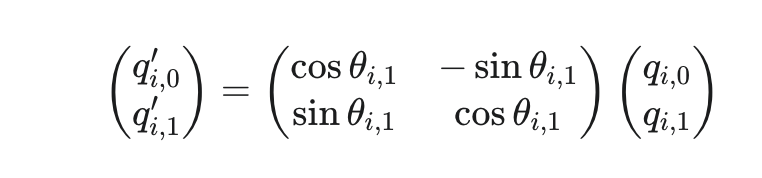利用旋转的性质计算的，
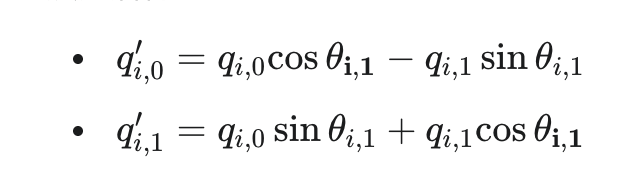

### section 3.5.4
- hint the same RoPE rotation should be applied to the query and key vectors for each head.
- 每个rope输入都是$d_head$

### section 3 final
- weight tying embedding w == head w
- cross-entro for training and perplexity for inference